# Módulo 07 - Tarefa 02

#### 1) Carregue a base e garanta que a base está como deveria.

Considere a base que você ajustou na lição passada. Carregue-a. Caso ainda haja alguma pendência, ajuste - lembre-se de que o scikitlearn não recebe variáveis em formato string, somente numéricas, e não aceita '*missings*'. 

- Separe 70% da base para treinamento e 30% para validação. Cada uma dessas partes terá dois objetos, um armazenando a variável resposta ```mau```e outro armazenando as variáveis explicativas (lembrando: sem variáveis string, já com as dummies).

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score

# carregar base
df = pd.read_csv('demo01.csv')

# visualizar
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16650 entries, 0 to 16649
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sexo                   16650 non-null  object 
 1   posse_de_veiculo       16650 non-null  object 
 2   posse_de_imovel        16650 non-null  object 
 3   qtd_filhos             16650 non-null  int64  
 4   tipo_renda             16650 non-null  object 
 5   educacao               16650 non-null  object 
 6   estado_civil           16650 non-null  object 
 7   tipo_residencia        16650 non-null  object 
 8   idade                  16650 non-null  float64
 9   tempo_emprego          16650 non-null  float64
 10  possui_celular         16650 non-null  int64  
 11  possui_fone_comercial  16650 non-null  int64  
 12  possui_fone            16650 non-null  int64  
 13  possui_email           16650 non-null  int64  
 14  qt_pessoas_residencia  16650 non-null  float64
 15  ma

In [23]:
#Converter variáveis categóricas em numéricasdf.info()
df_dummies = pd.get_dummies(df, drop_first=True)

In [25]:
#Separar variável resposta e explicativas
y = df_dummies['mau']
X = df_dummies.drop('mau', axis=1)

In [27]:
# Separar base de treino e teste 70% treino e 30% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

#### 2) Vamos para o modelo:

1. Defina um objeto com a função da árvore de decisão vista em aula.
2. Treine o modelo com os dados que você separou para treinamento.
3. Visualize a árvore. Talvez você queira aumentar um pouco a figura.
4. Produza uma visualização da matriz de classificação (ou matriz de confusão) - coloque os rótulos como "aprovados" e "reprovados" - pois afinal de contas, são essas as decisões que se podem tomar com propostas de crédito.
5. Calcule a acurácia na base de treinamento

In [29]:
# 1) Criar modelo de Árvore de Decisão

tree = DecisionTreeClassifier()

# DecisionTreeClassifier()
# cria um modelo de árvore de decisão para classificação.

# tree
# objeto que armazenará o modelo.

In [31]:
# 2) Treinar o modelo

tree.fit(X_train, y_train)

# Explicação
# fit()
# método que treina o modelo

# X_train
# variáveis explicativas

# y_train
# variável resposta.

DecisionTreeClassifier()

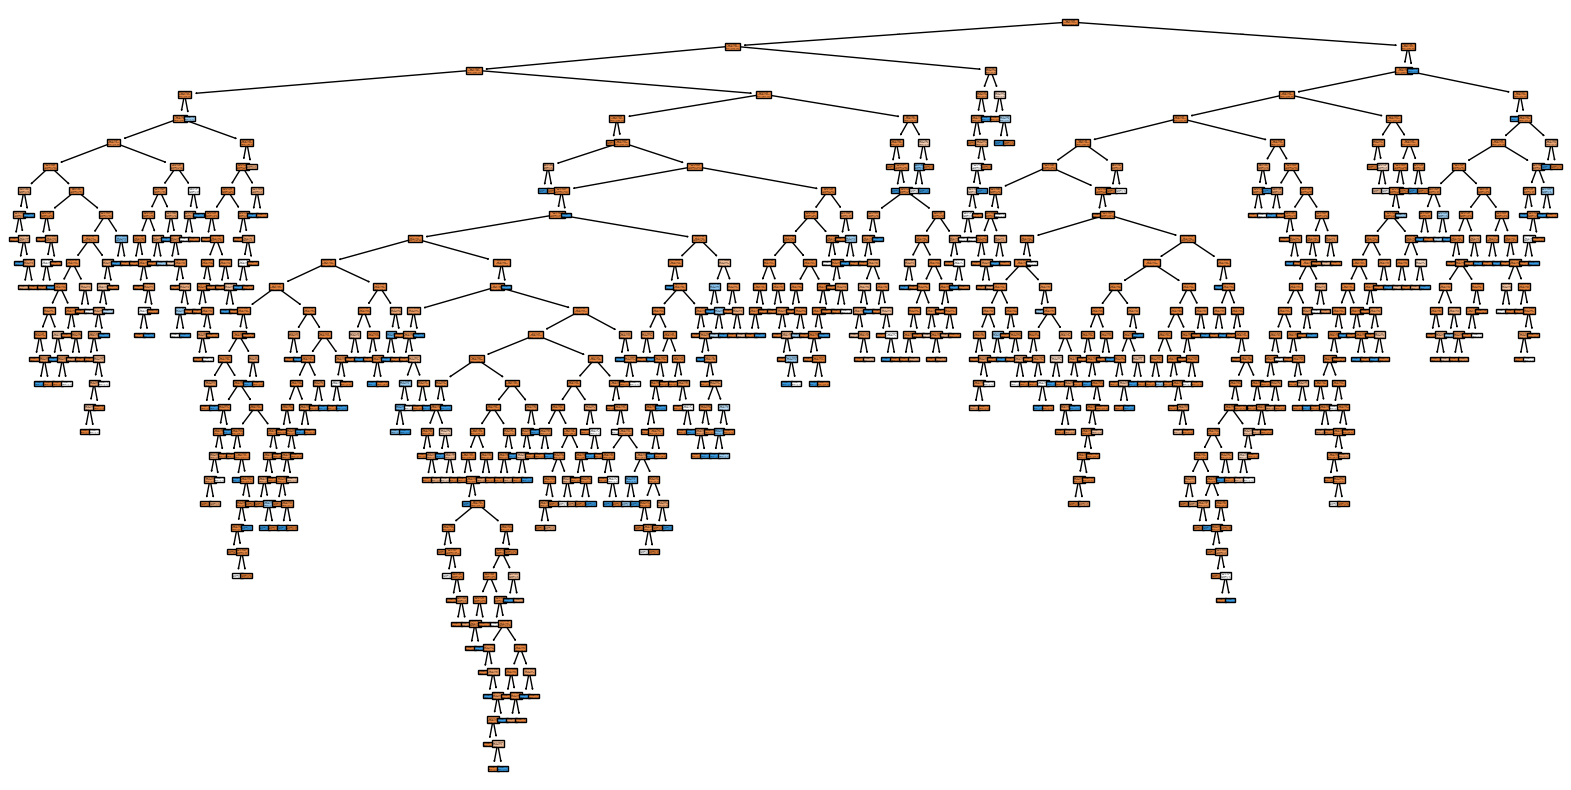

In [33]:
# 3) Visualizar a árvore

plt.figure(figsize=(20,10))
plot_tree(tree, filled=True)
plt.show()

# Explicação
# plt.figure(figsize=(20,10))
# define o tamanho da figura

# plot_tree(tree)
# plota a árvore de decisão

# filled=True
# colore os nós para facilitar a interpretação.

# plt.show()
# exibe o gráfico.

In [34]:
# 4) Fazer previsões na base de treino

y_pred_train = tree.predict(X_train)

# Explicação
# predict()
# gera as previsões do modelo

# y_pred_train
# armazena as previsões.

In [35]:
#4.1) Criar matriz de confusão (treino)

cm_train = confusion_matrix(y_train, y_pred_train)

# Explicação
# confusion_matrix()
# compara valores reais vs previstos.

# Estrutura:
# |          | Previsto Bom | Previsto Mau |
# | -------- | ------------ | ------------ |
# | Real Bom | acerto       | erro         |
# | Real Mau | erro         | acerto       |


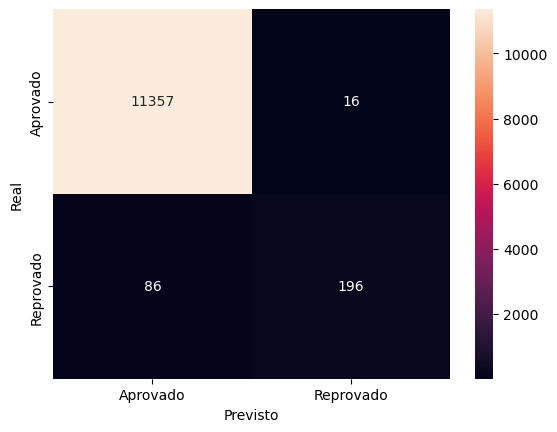

In [36]:
# 4.2) Visualizar matriz
sns.heatmap(cm_train,
            annot=True,
            fmt='d',
            xticklabels=['Aprovado','Reprovado'],
            yticklabels=['Aprovado','Reprovado'])

plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

# Explicação:
# sns.heatmap()

# cria mapa de calor da matriz
# annot=True
# mostra os números dentro das células.

# fmt='d'
# formato inteiro.

# xticklabels
# rótulos do eixo X (previsão)

# yticklabels
# rótulos do eixo Y (real).

In [39]:
# 5) Calcular acurácia (treino)
acc_train = accuracy_score(y_train, y_pred_train)
print(acc_train)

# Explicação
# accuracy_score()
# mede proporção de acertos

#Fórmula: acuuracy = (acertos/total)


0.9912483912483913


#### 3) Vamos avaliar o modelo na base de testes

1. Classifique a base de teste de acordo com a árvore que você treinou no item 2.
2. Produza a visualização da matriz de confusão para a base de teste.
3. Calcule a acurácia da base de teste. Compare com a acurácia da base de treinamento.
4. Treine uma nova árvore com número mínimo de observações por folha de 5 e máximo de profundidade de 10. Use o random_state = 123. Avalie a matriz de classificação. Observe a distribuição da predição - qual a proporção de proponentes foram classificados como 'maus'?
5. Como ficaria a acurácia se você classificasse todos os contratos como 'bons'?

In [47]:
# 1) Avaliar modelo na base de teste
y_pred_test = tree.predict(X_test)

# Explicação:
# usa o modelo treinado para classificar novos dados.

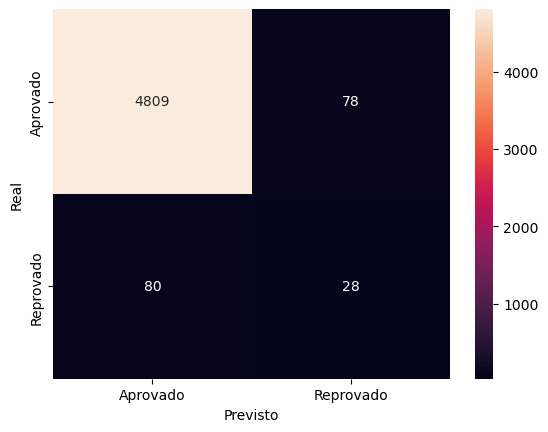

In [49]:
# 2) matriz de confusão
cm_test = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm_test,
            annot=True,
            fmt='d',
            xticklabels=['Aprovado','Reprovado'],
            yticklabels=['Aprovado','Reprovado'])

plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()


In [51]:
# 3) Acurácia teste
acc_test = accuracy_score(y_test, y_pred_test)
print(acc_test)

0.9683683683683684


In [57]:
# acurácia na base de treino
acc_train = accuracy_score(y_train, y_pred_train)

# acurácia na base de teste
acc_test = accuracy_score(y_test, y_pred_test)

print("Acurácia treino:", acc_train)
print("Acurácia teste:", acc_test)


# Explicação
# acc_train
# variável que armazena a acurácia do treinamento

# acc_test
# variável que armazena a acurácia do teste

#Se treino >> teste → overfitting

Acurácia treino: 0.9912483912483913
Acurácia teste: 0.9683683683683684


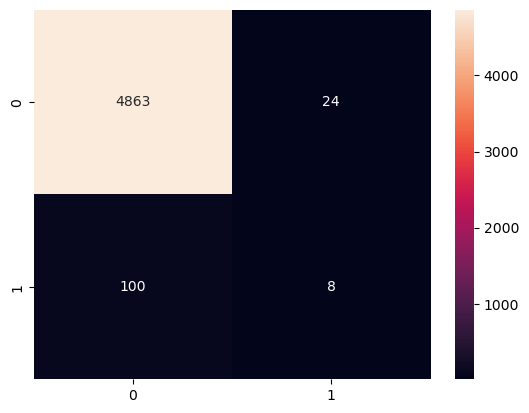

In [59]:
# 4) Nova árvore com restrições. Agora vamos controlar o overfitting.
tree2 = DecisionTreeClassifier(
    min_samples_leaf=5,
    max_depth=10,
    random_state=123
)

#Treinar nova árvore
tree2.fit(X_train, y_train)

#Previsão
y_pred_test2 = tree2.predict(X_test)

#Matriz de confusão
cm_test2 = confusion_matrix(y_test, y_pred_test2)
sns.heatmap(cm_test2, annot=True, fmt='d')
plt.show()

# Explicação
# min_samples_leaf=5
# cada folha precisa ter pelo menos 5 observações

# max_depth=10
# limita profundidade da árvore

# random_state=123
# garante reprodutibilidade.

In [61]:
# 4.1) Proporção de clientes classificados como maus. 
np.mean(y_pred_test2)

# Explicação:
# Se:
# 0 = bom
# 1 = mau
# A média será % de maus classificados pelo modelo.

0.006406406406406407

In [ ]:
# 5) Acurácia classificando todos como bons. Agora vamos simular um modelo bobo.
y_pred_dummy = np.zeros(len(y_test))

# Explicação:
# np.zeros()
# cria vetor só com 0
# Ou seja:
# todos são classificados como bons pagadores.



In [ ]:
#Calcular acurácia
accuracy_score(y_test, y_pred_dummy)

# Isso mostra:
# se o modelo de árvore é realmente melhor que um modelo trivial.

In [ ]:
#Resumo conceitual

#Fluxo completo:

# Carregar dados
#      ↓
# Limpar dados
#      ↓
# Criar dummies
#      ↓
# Separar X e y
#      ↓
# Dividir treino/teste
#      ↓
# Treinar árvore
#      ↓
# Avaliar (matriz + acurácia)
#      ↓
# Ajustar hiperparâmetros
#      ↓
# Comparar com modelo trivial
